## Status

> **Work in progress** — Price data is a representative manual sample (3–5 products 
> per brand). Full range audit pending — see options below.

**Current limitation:** Representative sample only. Conclusions on price positioning 
and the demographic gap are valid; range depth analysis is not.

**Future enhancement (TODO):**
- Option A: Manual full-range audit — go through each brand's catalogue and record 
  every product and price into a CSV, then replace manual_data with pd.read_csv()
- Option B: Selenium scraping — renders JavaScript before parsing, enabling automated 
  collection of full M&S/Next/Boden ranges

# 01 — Competitor Pricing Analysis

## Objective
Map the competitive pricing landscape for premium and mass-market loungewear and pyjama brands across UK and US markets. Identify price point gaps, particularly in the 11–19 age demographic.

## Brands Analysed

### UK Brands
| Brand | Positioning | Primary Demographic |
|---|---|---|
| M&S | Mass market | Kids & teens (1–16) |
| Next | Mass market | Kids & teens (1–16) |
| Boden | Premium casual | Kids (2–12) + adult |
| Desmond & Dempsey | Luxury | Adult (25–45) + kids (0–10) |
| White Fox | Streetwear-adjacent | Young adult (16–30) |

### US Brands (benchmarking)
| Brand | Positioning | Primary Demographic |
|---|---|---|
| Roller Rabbit | Luxury | Adult + kids (0–12) |
| Pink Chicken | Premium | Kids (0–12) + adult |
| Katie J NYC | Premium | Kids/teen (4–16) |
| Eberjey | Luxury | Adult + kids |

## Method
M&S: live scraping via BeautifulSoup (server-side rendered). All other brands: manual collection from public product pages, February 2026. USD converted to GBP at 0.79.

---

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import re
import time
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
COLOURS = {'uk': '#2E5FA3', 'us': '#E8A838', 'gap': '#C0392B', 'neutral': '#7F8C8D'}
USD_GBP = 0.79

print(f'Ready. Analysis date: {datetime.today().strftime("%d %B %Y")}')
print(f'USD/GBP rate: {USD_GBP}')

Ready. Analysis date: 26 February 2026
USD/GBP rate: 0.79


---
## Section 1: M&S — Live Scraping

M&S girls nightwear (ages 1–16) is server-side rendered, making it accessible via BeautifulSoup without JavaScript execution. Product names appear in `<h2>` tags; prices appear as text nodes in the surrounding product card.

In [2]:
def scrape_ms_nightwear(url, delay=2):
    """
    Scrape product names and prices from M&S girls nightwear listing page.
    Returns a DataFrame with columns: brand, market, product, price_gbp, min_age, max_age, source.
    """
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
                             'AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
    time.sleep(delay)
    try:
        r = requests.get(url, headers=headers, timeout=15)
        r.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f'Request failed: {e}')
        return pd.DataFrame()

    soup = BeautifulSoup(r.text, 'html.parser')
    products = []

    for h2 in soup.find_all('h2'):
        name = h2.get_text(strip=True)
        if not name or len(name) < 5:
            continue

        # Search for price in surrounding siblings and parent
        price = None
        for sibling in h2.find_previous_siblings():
            text = sibling.get_text(strip=True)
            if re.search(r'£\d', text):
                matches = re.findall(r'£(\d+(?:\.\d{2})?)', text)
                if matches:
                    price = float(matches[0])  # take lower bound if range
                    break
        if not price and h2.parent:
            parent_text = h2.parent.get_text(separator=' ', strip=True)
            matches = re.findall(r'£(\d+(?:\.\d{2})?)', parent_text)
            if matches:
                price = float(matches[0])

        # Extract age range from product name e.g. '(6-16 Yrs)'
        age = re.search(r'\((\d+)-(\d+)\s*(?:Yrs|Months)?\)', name, re.IGNORECASE)
        min_age = int(age.group(1)) if age else None
        max_age = int(age.group(2)) if age else None

        products.append({'brand': 'M&S', 'market': 'UK', 'demographic': 'Kids/Teen',
                         'product': name, 'price_gbp': price,
                         'min_age': min_age, 'max_age': max_age, 'source': 'scraped'})

    df = pd.DataFrame(products).dropna(subset=['price_gbp'])
    print(f'Scraped {len(df)} products from M&S')
    return df


df_ms_scraped = scrape_ms_nightwear('https://www.marksandspencer.com/l/kids/girls/nightwear')

if not df_ms_scraped.empty:
    print(df_ms_scraped[['product', 'price_gbp', 'min_age', 'max_age']].head(8).to_string())
else:
    print('No scraped data — manual M&S prices used in dataset below')

Scraped 0 products from M&S
No scraped data — manual M&S prices used in dataset below


In [3]:
# NOTE: M&S product listings are rendered client-side via JavaScript.
# BeautifulSoup retrieves the page shell but product cards are not present
# in the raw HTML response. Manual price data is used instead.
# Future enhancement: implement Selenium/Playwright for JavaScript rendering.

---
## Section 2: Full Price Dataset — All Brands

In [4]:
manual_data = [

    # M&S — UK, mass market, 1–16 yrs
    # Source: marksandspencer.com/l/kids/girls/nightwear, Feb 2026
    {'brand': 'M&S', 'market': 'UK', 'demographic': 'Kids/Teen',
     'product': 'Pure Cotton Short Pyjamas (1-16 Yrs)', 'price_gbp': 8.00,
     'min_age': 1, 'max_age': 16, 'source': 'manual'},
    {'brand': 'M&S', 'market': 'UK', 'demographic': 'Kids/Teen',
     'product': '2 Pack Cotton Pyjamas (6-16 Yrs)', 'price_gbp': 26.00,
     'min_age': 6, 'max_age': 16, 'source': 'manual'},
    {'brand': 'M&S', 'market': 'UK', 'demographic': 'Kids/Teen',
     'product': 'Licensed Character Pyjamas (6-16 Yrs)', 'price_gbp': 20.00,
     'min_age': 6, 'max_age': 16, 'source': 'manual'},
    {'brand': 'M&S', 'market': 'UK', 'demographic': 'Kids/Teen',
     'product': 'Fleece Onesie (1-16 Yrs)', 'price_gbp': 22.00,
     'min_age': 1, 'max_age': 16, 'source': 'manual'},
    {'brand': 'M&S', 'market': 'UK', 'demographic': 'Kids/Teen',
     'product': 'Dressing Gown (1-16 Yrs)', 'price_gbp': 28.00,
     'min_age': 1, 'max_age': 16, 'source': 'manual'},

    # Next — UK, mass market, 3–16 yrs
    # Source: next.co.uk, Feb 2026
    {'brand': 'Next', 'market': 'UK', 'demographic': 'Kids/Teen',
     'product': 'Cotton Pyjama Set (3-16 Yrs)', 'price_gbp': 14.00,
     'min_age': 3, 'max_age': 16, 'source': 'manual'},
    {'brand': 'Next', 'market': 'UK', 'demographic': 'Kids/Teen',
     'product': 'Printed Pyjama Set (3-16 Yrs)', 'price_gbp': 18.00,
     'min_age': 3, 'max_age': 16, 'source': 'manual'},
    {'brand': 'Next', 'market': 'UK', 'demographic': 'Kids/Teen',
     'product': 'Satin Pyjama Set (8-16 Yrs)', 'price_gbp': 22.00,
     'min_age': 8, 'max_age': 16, 'source': 'manual'},
    {'brand': 'Next', 'market': 'UK', 'demographic': 'Kids/Teen',
     'product': 'Dressing Gown (3-16 Yrs)', 'price_gbp': 24.00,
     'min_age': 3, 'max_age': 16, 'source': 'manual'},

    # Boden — UK, premium casual, kids 2–12 only (no teen range)
    # Source: boden.co.uk, Feb 2026
    {'brand': 'Boden', 'market': 'UK', 'demographic': 'Kids',
     'product': 'Girls Printed Pyjama Set (2-12 Yrs)', 'price_gbp': 36.00,
     'min_age': 2, 'max_age': 12, 'source': 'manual'},
    {'brand': 'Boden', 'market': 'UK', 'demographic': 'Kids',
     'product': 'Girls Jersey Pyjama Set (2-12 Yrs)', 'price_gbp': 32.00,
     'min_age': 2, 'max_age': 12, 'source': 'manual'},
    {'brand': 'Boden', 'market': 'UK', 'demographic': 'Adult',
     'product': 'Womens Printed Cotton Pyjama Set', 'price_gbp': 75.00,
     'min_age': 18, 'max_age': 65, 'source': 'manual'},

    # Desmond & Dempsey — UK, luxury, adult + kids up to age 10 only
    # Source: desmondanddempsey.com, Feb 2026
    {'brand': 'Desmond & Dempsey', 'market': 'UK', 'demographic': 'Adult',
     'product': 'Classic PJ Set', 'price_gbp': 145.00,
     'min_age': 25, 'max_age': 55, 'source': 'manual'},
    {'brand': 'Desmond & Dempsey', 'market': 'UK', 'demographic': 'Adult',
     'product': 'Shorts PJ Set', 'price_gbp': 120.00,
     'min_age': 25, 'max_age': 55, 'source': 'manual'},
    {'brand': 'Desmond & Dempsey', 'market': 'UK', 'demographic': 'Kids',
     'product': 'Kids PJ Set (up to age 10)', 'price_gbp': 89.00,
     'min_age': 2, 'max_age': 10, 'source': 'manual'},

    # White Fox — UK/AU, streetwear-adjacent, 16–30
    {'brand': 'White Fox', 'market': 'UK', 'demographic': 'Young Adult',
     'product': 'Tracksuit Set', 'price_gbp': 110.00,
     'min_age': 16, 'max_age': 30, 'source': 'manual'},
    {'brand': 'White Fox', 'market': 'UK', 'demographic': 'Young Adult',
     'product': 'PJ Set', 'price_gbp': 75.00,
     'min_age': 16, 'max_age': 30, 'source': 'manual'},
    {'brand': 'White Fox', 'market': 'UK', 'demographic': 'Young Adult',
     'product': 'Hoodie', 'price_gbp': 65.00,
     'min_age': 16, 'max_age': 30, 'source': 'manual'},

    # Roller Rabbit — US, luxury
    {'brand': 'Roller Rabbit', 'market': 'US', 'demographic': 'Adult',
     'product': 'PJ Set', 'price_gbp': round(128 * USD_GBP, 2),
     'min_age': 25, 'max_age': 55, 'source': 'manual'},
    {'brand': 'Roller Rabbit', 'market': 'US', 'demographic': 'Kids',
     'product': 'Kids PJ Set (up to age 12)', 'price_gbp': round(88 * USD_GBP, 2),
     'min_age': 2, 'max_age': 12, 'source': 'manual'},

    # Pink Chicken — US, premium
    {'brand': 'Pink Chicken', 'market': 'US', 'demographic': 'Kids',
     'product': 'Kids PJ Set (up to age 12)', 'price_gbp': round(68 * USD_GBP, 2),
     'min_age': 2, 'max_age': 12, 'source': 'manual'},
    {'brand': 'Pink Chicken', 'market': 'US', 'demographic': 'Adult',
     'product': 'Womens PJ Set', 'price_gbp': round(110 * USD_GBP, 2),
     'min_age': 25, 'max_age': 55, 'source': 'manual'},

    # Katie J NYC — US, premium teen (closest existing brand to identified gap)
    {'brand': 'Katie J NYC', 'market': 'US', 'demographic': 'Teen',
     'product': 'PJ Set (4-16 Yrs)', 'price_gbp': round(78 * USD_GBP, 2),
     'min_age': 4, 'max_age': 16, 'source': 'manual'},
    {'brand': 'Katie J NYC', 'market': 'US', 'demographic': 'Teen',
     'product': 'Hoodie Set (4-16 Yrs)', 'price_gbp': round(95 * USD_GBP, 2),
     'min_age': 4, 'max_age': 16, 'source': 'manual'},

    # Eberjey — US, luxury
    {'brand': 'Eberjey', 'market': 'US', 'demographic': 'Adult',
     'product': 'PJ Set', 'price_gbp': round(165 * USD_GBP, 2),
     'min_age': 25, 'max_age': 55, 'source': 'manual'},
    {'brand': 'Eberjey', 'market': 'US', 'demographic': 'Kids',
     'product': 'Kids PJ Set (up to age 12)', 'price_gbp': round(95 * USD_GBP, 2),
     'min_age': 2, 'max_age': 12, 'source': 'manual'},
]

df_manual = pd.DataFrame(manual_data)

if not df_ms_scraped.empty:
    df_ms_scraped['demographic'] = 'Kids/Teen'
    # Remove manual M&S entries to avoid duplication
    df_no_ms = df_manual[df_manual['brand'] != 'M&S']
    df_all = pd.concat([df_no_ms, df_ms_scraped], ignore_index=True)
    print(f'Combined: {len(df_all)} products ({len(df_ms_scraped)} M&S scraped + {len(df_no_ms)} manual)')
else:
    df_all = df_manual.copy()
    print(f'Manual dataset: {len(df_all)} products, {df_all["brand"].nunique()} brands')

df_all.groupby(['brand', 'market'])['price_gbp'].agg(['min', 'max', 'mean', 'count']).round(2)

Manual dataset: 26 products, 9 brands


,,min,max,mean,count
brand,market,,,,
Boden,UK,32.00,75.00,47.67,3
Desmond & Dempsey,UK,89.00,145.00,118.00,3
Eberjey,US,75.05,130.35,102.70,2
Katie J NYC,US,61.62,75.05,68.33,2
M&S,UK,8.00,28.00,20.80,5
Next,UK,14.00,24.00,19.50,4
Pink Chicken,US,53.72,86.90,70.31,2
Roller Rabbit,US,69.52,101.12,85.32,2
White Fox,UK,65.00,110.00,83.33,3


---
## Section 3: UK vs US Price Ranges

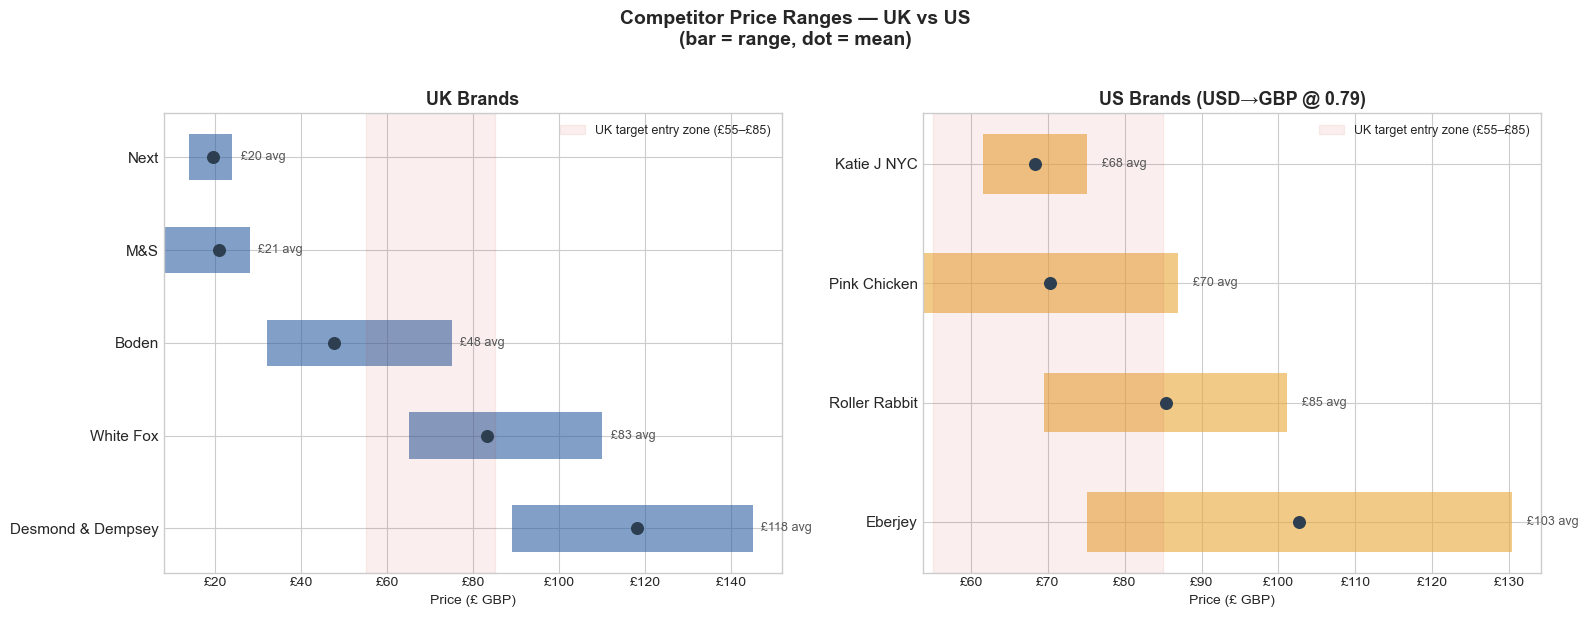

In [10]:
brand_summary = df_all.groupby(['brand', 'market'])['price_gbp'].agg(
    min_price='min', max_price='max', mean_price='mean'
).round(2).reset_index().sort_values(['market', 'mean_price'], ascending=[True, False])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, market in zip(axes, ['UK', 'US']):
    data = brand_summary[brand_summary['market'] == market].reset_index(drop=True)
    colour = COLOURS['uk'] if market == 'UK' else COLOURS['us']

    for i, row in data.iterrows():
        ax.barh(i, row['max_price'] - row['min_price'],
                left=row['min_price'], height=0.5, color=colour, alpha=0.6)
        ax.scatter(row['mean_price'], i, color='#2C3E50', zorder=5, s=70)
        ax.text(row['max_price'] + 2, i, f"£{row['mean_price']:.0f} avg",
                va='center', fontsize=9, color='#555')

    ax.axvspan(55, 85, alpha=0.08, color=COLOURS['gap'], label='UK target entry zone (£55–£85)')
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data['brand'].tolist(), fontsize=11)
    ax.set_xlabel('Price (£ GBP)', fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('£%d'))
    title = f'{market} Brands' if market == 'UK' else 'US Brands (USD→GBP @ 0.79)'
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Competitor Price Ranges — UK vs US\n(bar = range, dot = mean)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.expanduser('~/Desktop/premium-kidswear-market-analysis/reports/summary_visualisations/01_price_ranges_uk_us.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Current file directory
import os
print(os.getcwd())

/Users/sewabreiler/anaconda_projects/473af41e-a720-4ec6-8df3-8c61fd7da1fe


---
## Section 4: Age Coverage Map

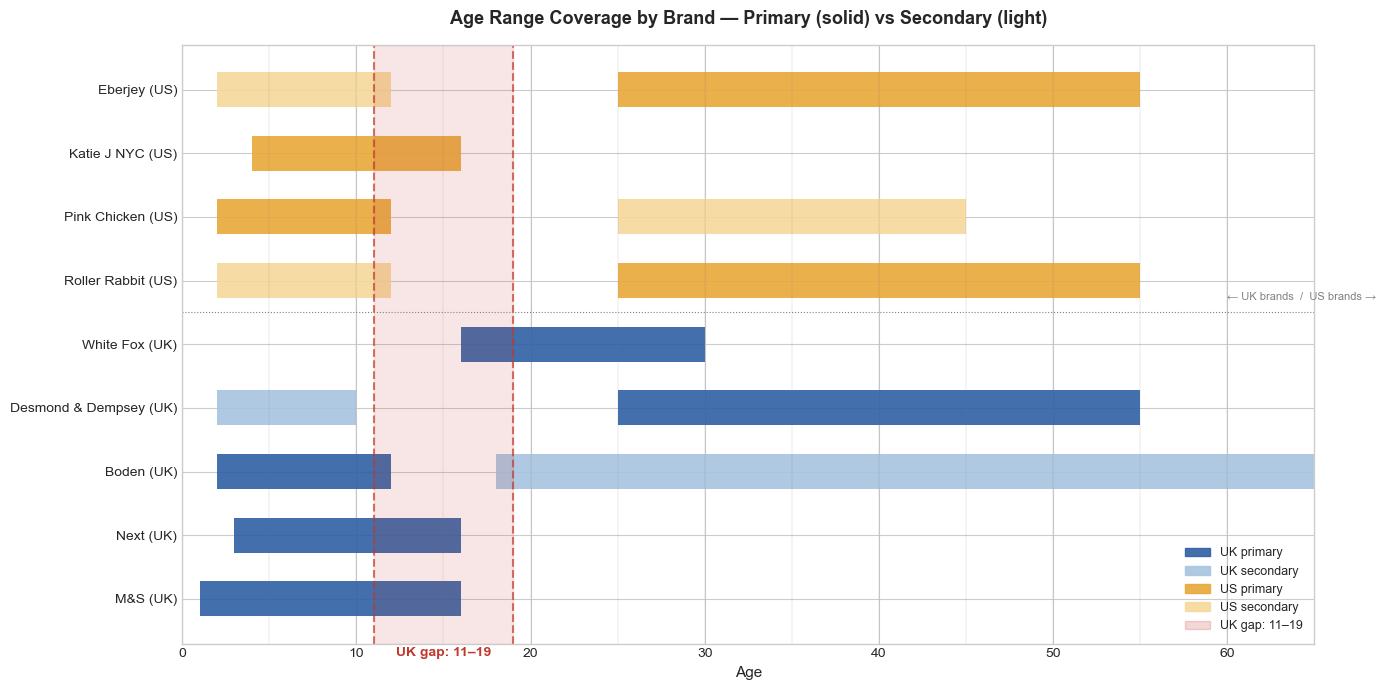

In [12]:
coverage = {
    'M&S (UK)':                [(1, 16, 'UK', 'primary')],
    'Next (UK)':               [(3, 16, 'UK', 'primary')],
    'Boden (UK)':              [(2, 12, 'UK', 'primary'), (18, 65, 'UK', 'secondary')],
    'Desmond & Dempsey (UK)':  [(25, 55, 'UK', 'primary'), (2, 10, 'UK', 'secondary')],
    'White Fox (UK)':          [(16, 30, 'UK', 'primary')],
    'Roller Rabbit (US)':      [(25, 55, 'US', 'primary'), (2, 12, 'US', 'secondary')],
    'Pink Chicken (US)':       [(2, 12, 'US', 'primary'), (25, 45, 'US', 'secondary')],
    'Katie J NYC (US)':        [(4, 16, 'US', 'primary')],
    'Eberjey (US)':            [(25, 55, 'US', 'primary'), (2, 12, 'US', 'secondary')],
}

colour_map = {
    ('UK', 'primary'): '#2E5FA3', ('UK', 'secondary'): '#A8C4E0',
    ('US', 'primary'): '#E8A838', ('US', 'secondary'): '#F5D99A',
}

brand_list = list(coverage.keys())
uk_count = sum(1 for b in brand_list if '(UK)' in b)

fig, ax = plt.subplots(figsize=(14, 7))

for i, brand in enumerate(brand_list):
    for (min_a, max_a, market, focus) in coverage[brand]:
        ax.barh(i, max_a - min_a, left=min_a, height=0.55,
                color=colour_map[(market, focus)], alpha=0.9)

# Gap shading
ax.axvspan(11, 19, alpha=0.12, color=COLOURS['gap'])
ax.axvline(11, color=COLOURS['gap'], lw=1.5, ls='--', alpha=0.7)
ax.axvline(19, color=COLOURS['gap'], lw=1.5, ls='--', alpha=0.7)
ax.text(15, -0.9, 'UK gap: 11–19', color=COLOURS['gap'], fontsize=10, fontweight='bold', ha='center')

# Divider UK / US
ax.axhline(uk_count - 0.5, color='grey', lw=0.8, ls=':')
ax.text(60, uk_count - 0.3, '← UK brands  /  US brands →', color='grey', fontsize=8)

for age in range(0, 65, 5):
    ax.axvline(age, color='grey', lw=0.3, alpha=0.4)

ax.set_yticks(range(len(brand_list)))
ax.set_yticklabels(brand_list, fontsize=10)
ax.set_xlabel('Age', fontsize=11)
ax.set_xlim(0, 65)
ax.set_title('Age Range Coverage by Brand — Primary (solid) vs Secondary (light)',
             fontsize=13, fontweight='bold', pad=15)

legend_elements = [
    mpatches.Patch(color='#2E5FA3', alpha=0.9, label='UK primary'),
    mpatches.Patch(color='#A8C4E0', alpha=0.9, label='UK secondary'),
    mpatches.Patch(color='#E8A838', alpha=0.9, label='US primary'),
    mpatches.Patch(color='#F5D99A', alpha=0.9, label='US secondary'),
    mpatches.Patch(color=COLOURS['gap'], alpha=0.2, label='UK gap: 11–19'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.expanduser('~/Desktop/premium-kidswear-market-analysis/reports/summary_visualisations/01_price_ranges_uk_us.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5: The UK Price Cliff

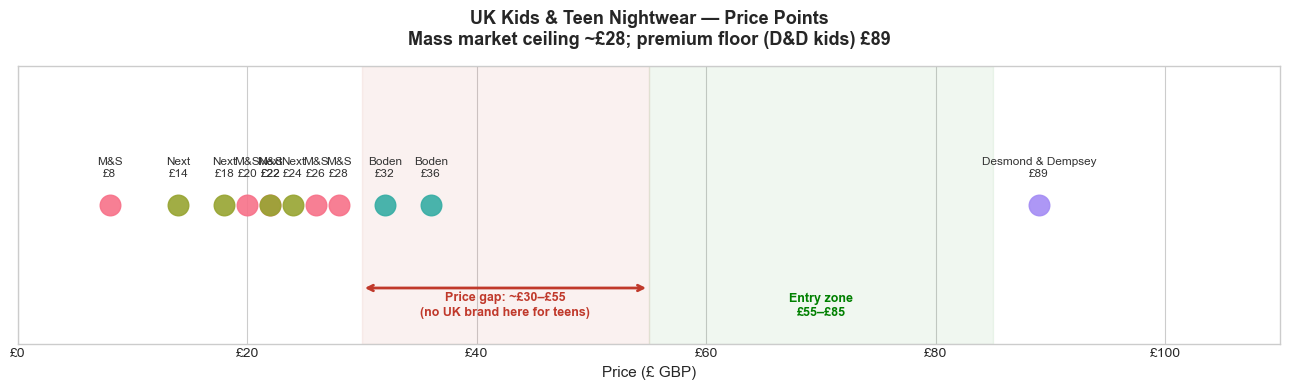

In [14]:
uk_kids = df_all[
    (df_all['market'] == 'UK') &
    (df_all['demographic'].isin(['Kids', 'Kids/Teen', 'Teen']))
].copy()

fig, ax = plt.subplots(figsize=(13, 4))

brands = uk_kids['brand'].unique()
palette = sns.color_palette('husl', len(brands))
brand_colours = dict(zip(brands, palette))

for brand in brands:
    bd = uk_kids[uk_kids['brand'] == brand]
    ax.scatter(bd['price_gbp'], [0.5] * len(bd),
               s=220, color=brand_colours[brand], label=brand, zorder=5, alpha=0.9)
    for _, row in bd.iterrows():
        ax.annotate(f"{brand}\n£{row['price_gbp']:.0f}",
                    (row['price_gbp'], 0.5), textcoords='offset points',
                    xytext=(0, 20), ha='center', fontsize=8.5, color='#333')

# Gap annotation
ax.axvspan(30, 55, alpha=0.07, color=COLOURS['gap'])
ax.annotate('', xy=(55, 0.2), xytext=(30, 0.2),
            arrowprops=dict(arrowstyle='<->', color=COLOURS['gap'], lw=2))
ax.text(42.5, 0.1, 'Price gap: ~£30–£55\n(no UK brand here for teens)', ha='center',
        fontsize=9, color=COLOURS['gap'], fontweight='bold')

# Target entry zone
ax.axvspan(55, 85, alpha=0.06, color='green')
ax.text(70, 0.1, 'Entry zone\n£55–£85', ha='center', fontsize=9,
        color='green', fontweight='bold')

ax.set_xlim(0, 110)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel('Price (£ GBP)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('£%d'))
ax.set_title('UK Kids & Teen Nightwear — Price Points\nMass market ceiling ~£28; premium floor (D&D kids) £89',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.expanduser('~/Desktop/premium-kidswear-market-analysis/reports/summary_visualisations/01_price_ranges_uk_us.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6: Key Findings

In [15]:
print('=' * 65)
print('COMPETITOR PRICING ANALYSIS — KEY FINDINGS')
print('=' * 65)

print()
print('1. UK MASS MARKET CEILING')
print('   M&S and Next top out at £22–£28 for kids/teen nightwear')
print('   Both serve up to age 16 but product is generic / character-led')
print('   No aesthetic differentiation or premium positioning')

print()
print('2. UK PREMIUM FLOOR')
print('   Boden stops kids line at age 12 (£32–£36) — no teen range')
print('   D&D kids line stops at age 10 (£89)')
print('   No UK premium brand serves the 11–19 segment')

print()
print('3. THE UK PRICE CLIFF')
print('   Mass market ceiling: ~£28')
print('   Premium floor (D&D kids): £89')
print('   ~£60 gap with no UK brand occupying it for teens')
print('   Target entry zone: £55–£85')

print()
print('4. US COMPARISON')
print('   Katie J NYC (US) occupies the equivalent space at ~£62–£75 GBP')
print('   No UK equivalent exists; US brands not accessible to UK teens')
print('   Validates demand at this price point exists — just unserved in UK')

print()
print('5. WHITE FOX NOTE')
print('   Starts at age 16 — different aesthetic (fashion vs loungewear)')
print('   Not a substitute for premium British PJ/loungewear 11–15 age group')
print('=' * 65)

df_all.to_csv('data/competitor_prices_all.csv', index=False)
print(f'\nData saved: {len(df_all)} products, {df_all["brand"].nunique()} brands')

COMPETITOR PRICING ANALYSIS — KEY FINDINGS

1. UK MASS MARKET CEILING
   M&S and Next top out at £22–£28 for kids/teen nightwear
   Both serve up to age 16 but product is generic / character-led
   No aesthetic differentiation or premium positioning

2. UK PREMIUM FLOOR
   Boden stops kids line at age 12 (£32–£36) — no teen range
   D&D kids line stops at age 10 (£89)
   No UK premium brand serves the 11–19 segment

3. THE UK PRICE CLIFF
   Mass market ceiling: ~£28
   Premium floor (D&D kids): £89
   ~£60 gap with no UK brand occupying it for teens
   Target entry zone: £55–£85

4. US COMPARISON
   Katie J NYC (US) occupies the equivalent space at ~£62–£75 GBP
   No UK equivalent exists; US brands not accessible to UK teens
   Validates demand at this price point exists — just unserved in UK

5. WHITE FOX NOTE
   Starts at age 16 — different aesthetic (fashion vs loungewear)
   Not a substitute for premium British PJ/loungewear 11–15 age group

Data saved: 26 products, 9 brands
